# Experiment 1.3.3 — Linear vs small temporal CNN vs GRU

This notebook extends Experiment 1.3.2 with a **small GRU decoder** while keeping the same direct 30-channel unsigned event representations and the same 5 user-disjoint splits.

Research question:

> **Does recurrent sequential modeling recover class information beyond a global Linear probe and a small local temporal CNN?**

Representations:
1. raw 64 Hz timestep sequence
2. fixed ~100 ms bins
3. fixed 250 ms bins
4. fixed 500 ms bins
5. relative 10-bin gesture-progress sequence

Decoders:
- Linear: flatten `[T,30] -> [30T]` and fit Logistic Regression
- CNN: `Conv1d(30->32,k=3) -> ReLU -> Conv1d(32->32,k=3) -> ReLU -> masked GAP -> Linear`
- GRU: `GRU(30->32, 1 layer) -> final valid hidden state -> Linear`

CNN and GRU share the same train-only RMS-scaled input tensor. GRU uses `pack_padded_sequence`, so right padding never updates recurrent state. Validation Balanced Accuracy selects the checkpoint; test data is never used for model selection.

In [1]:
from pathlib import Path
import copy, hashlib, os, random, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate writingRing repository root")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print("Repository root:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Repository root: /home/ted/project/writingRing
PyTorch: 2.11.0+cu128
CUDA available: True


## 1. Configuration

In [2]:
ACTION0_COMBINATION_DIR = REPO_ROOT / "outputs/action0_wavelets_0e5_1_2_4_8_sr_64"
ACTION1_COMBINATION_DIR = REPO_ROOT / "outputs/action1_wavelets_0e5_1_2_4_8_sr_64"
DATASET_ROOTS = [
    ACTION0_COMBINATION_DIR / "low-pass/aligned-board-events/segmentation_padded",
    ACTION1_COMBINATION_DIR / "low-pass/aligned-board-events/segmentation_padded",
]

EXPECTED_EVENT_REPRESENTATION = "unsigned"
EXPECTED_EVENT_FEATURE_SCHEMA = "custom_wavelet_polarity_split_abs_events_v1"
EVENT_CHANNEL_COUNT = 30
TOTAL_CHANNEL_COUNT = 36
EXPECTED_SAMPLING_RATE_HZ = 64.0

INCLUDED_LABELS = ("A","B","C","D","E","X","G","H","I","J","K","L")

SPLIT_SEEDS = (11, 23, 37, 53, 71)
N_TRAIN_USERS, N_VAL_USERS, N_TEST_USERS = 12, 4, 4

FIXED_DURATIONS_MS = (100, 250, 500)
RELATIVE_N_BINS = 10

CNN_CHANNELS = 32
CNN_KERNEL_SIZE = 3
GRU_HIDDEN_SIZE = 32
GRU_NUM_LAYERS = 1

BATCH_SIZE = 64
MAX_EPOCHS = 200
MIN_EPOCHS = 20
EARLY_STOP_PATIENCE = 25
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0
MODEL_INIT_SEED = 2026
LOGREG_MAX_ITER = 5000

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PADDING_ZERO_TOL = 1e-12
RESULTS_DIR = REPO_ROOT / "notebooks/artifacts/experiment_1_3_3_temporal_decoder_comparison"
SAVE_CHECKPOINTS = False

print("Device:", DEVICE)
print("Split seeds:", SPLIT_SEEDS)

Device: cuda
Split seeds: (11, 23, 37, 53, 71)


## 2. Reproducibility

In [3]:
def derive_seed(master_seed: int, *parts: object) -> int:
    text = "|".join([str(master_seed), *(str(p) for p in parts)])
    return int.from_bytes(hashlib.sha256(text.encode()).digest()[:4], "little")

def seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)

seed_everything(MODEL_INIT_SEED)

## 3. Load and validate cohort

In [4]:
data = load_acceleration_data(DATASET_ROOTS, repository_root=REPO_ROOT, require_reconstruction=False)

rates = sorted({float(m.sampling_rate_hz) for m in data.producer_metadatas})
if len(rates) != 1:
    raise ValueError(f"Roots must share sampling rate, got {rates}")
SAMPLING_RATE_HZ = rates[0]
if not np.isclose(SAMPLING_RATE_HZ, EXPECTED_SAMPLING_RATE_HZ):
    raise ValueError(f"Expected {EXPECTED_SAMPLING_RATE_HZ} Hz, got {SAMPLING_RATE_HZ}")

for root, metadata in zip(data.padded_roots, data.producer_metadatas, strict=True):
    raw = metadata.raw
    if raw.get("event_representation") != EXPECTED_EVENT_REPRESENTATION:
        raise ValueError(f"{root}: wrong event_representation")
    if raw.get("event_feature_schema") != EXPECTED_EVENT_FEATURE_SCHEMA:
        raise ValueError(f"{root}: wrong event_feature_schema")
    if raw.get("event_channel_count") != EVENT_CHANNEL_COUNT or metadata.channel_count != TOTAL_CHANNEL_COUNT:
        raise ValueError(f"{root}: expected 30 event + 6 IMU channels")

rows=[]
keep=set(INCLUDED_LABELS)
for pi,p in enumerate(data.packages):
    if p.padded_spike_imu.shape[2] != TOTAL_CHANNEL_COUNT:
        raise ValueError(f"Unexpected channel count: {p.padded_spike_imu.shape}")
    ev=np.asarray(p.padded_spike_imu[...,:EVENT_CHANNEL_COUNT])
    if np.any(~np.isfinite(ev)) or np.any(ev<0):
        raise ValueError("Events must be finite and non-negative")
    for si,label in enumerate(p.labels.astype(str)):
        if label not in keep:
            continue
        rows.append(dict(
            package_index=pi,
            segment_index=si,
            user=str(p.user),
            action=str(p.action),
            label=str(label),
            valid_length=int(p.valid_lengths[si]),
            package_padded_length=int(p.padded_spike_imu.shape[1]),
            sample_id=f"{p.user}/action_{p.action}/{si}",
        ))

manifest=pd.DataFrame(rows)
labels_sorted=sorted(manifest.label.unique().tolist())
CLASS_TO_IDX={lab:i for i,lab in enumerate(labels_sorted)}
IDX_TO_CLASS={i:lab for lab,i in CLASS_TO_IDX.items()}
manifest["label_idx"]=manifest.label.map(CLASS_TO_IDX).astype(int)
N_CLASSES=len(labels_sorted)
GLOBAL_PADDED_LENGTH=int(manifest.package_padded_length.max())

print(f"Samples={len(manifest)} users={manifest.user.nunique()} classes={N_CLASSES}")
print("Labels:", labels_sorted)
print("Sampling rate:", SAMPLING_RATE_HZ)
print("Global padded length:", GLOBAL_PADDED_LENGTH)
display(manifest.head())

Samples=853 users=20 classes=12
Labels: ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'X']
Sampling rate: 64.0
Global padded length: 256


,package_index,segment_index,user,action,label,valid_length,package_padded_length,sample_id,label_idx
0,0,24,user_0,0,J,72,256,user_0/action_0/24,8
1,0,25,user_0,0,B,128,256,user_0/action_0/25,1
2,0,26,user_0,0,X,106,256,user_0/action_0/26,11
3,0,27,user_0,0,E,122,256,user_0/action_0/27,4
4,0,31,user_0,0,G,124,256,user_0/action_0/31,5


## 4. Padding and user-split checks

In [5]:
def check_event_padding_is_zero():
    bad=[]
    for r in manifest.itertuples(index=False):
        p=data.packages[int(r.package_index)]
        tail=np.asarray(p.padded_spike_imu[int(r.segment_index), int(r.valid_length):, :EVENT_CHANNEL_COUNT])
        mx=float(np.max(np.abs(tail))) if tail.size else 0.0
        if mx>PADDING_ZERO_TOL:
            bad.append((r.sample_id,mx))
    if bad:
        raise ValueError(f"Non-zero event padding found, first rows: {bad[:10]}")
    print("Padding contract verified.")

def make_user_split(split_seed:int):
    users=sorted(manifest.user.unique().tolist())
    if len(users)!=(N_TRAIN_USERS+N_VAL_USERS+N_TEST_USERS):
        raise ValueError(f"Expected 20 users, got {len(users)}")
    rng=np.random.default_rng(derive_seed(split_seed,"user_split"))
    perm=np.array(users,dtype=object); rng.shuffle(perm)
    tr=set(perm[:N_TRAIN_USERS]); va=set(perm[N_TRAIN_USERS:N_TRAIN_USERS+N_VAL_USERS]); te=set(perm[-N_TEST_USERS:])
    out=manifest.copy()
    out["split"]=out.user.map(lambda u:"train" if u in tr else ("val" if u in va else "test"))
    for s in ("train","val","test"):
        part=out[out.split==s]
        missing=sorted(set(labels_sorted)-set(part.label.unique()))
        if missing:
            raise ValueError(f"split_seed={split_seed} {s} missing classes {missing}")
    return out

check_event_padding_is_zero()

split_review=[]
for seed in SPLIT_SEEDS:
    sm=make_user_split(seed)
    for s in ("train","val","test"):
        part=sm[sm.split==s]
        split_review.append(dict(split_seed=seed, split=s, users=part.user.nunique(), samples=len(part),
                                 classes_present=part.label.nunique(), user_ids=",".join(sorted(part.user.unique()))))
split_review=pd.DataFrame(split_review)
display(split_review)

Padding contract verified.


,split_seed,split,users,samples,classes_present,user_ids
0,11,train,12,477,12,"user_0,user_10,user_13,user_15,user_18,user_19..."
1,11,val,4,168,12,"user_11,user_12,user_16,user_9"
2,11,test,4,208,12,"user_1,user_14,user_2,user_3"
3,23,train,12,495,12,"user_0,user_1,user_12,user_13,user_15,user_18,..."
4,23,val,4,181,12,"user_10,user_11,user_14,user_3"
5,23,test,4,177,12,"user_16,user_5,user_6,user_8"
6,37,train,12,519,12,"user_0,user_11,user_12,user_15,user_16,user_18..."
7,37,val,4,176,12,"user_1,user_13,user_20,user_5"
8,37,test,4,158,12,"user_10,user_14,user_4,user_9"
9,53,train,12,514,12,"user_1,user_10,user_12,user_13,user_14,user_15..."


## 5. Representation builders

In [6]:
def labels_for_df(df): return df.label_idx.to_numpy(np.int64)
def lengths_for_df(df): return df.valid_length.to_numpy(np.int64)

def build_global_padded_events(df):
    out=np.zeros((len(df),GLOBAL_PADDED_LENGTH,EVENT_CHANNEL_COUNT),np.float32)
    for j,r in enumerate(df.itertuples(index=False)):
        p=data.packages[int(r.package_index)]
        x=np.asarray(p.padded_spike_imu[int(r.segment_index),:,:EVENT_CHANNEL_COUNT],np.float32)
        out[j,:x.shape[0]]=x
    return out

def duration_ms_to_samples(ms):
    return max(1,int(np.rint(float(ms)*SAMPLING_RATE_HZ/1000.0)))

def raw_rep(df):
    X=build_global_padded_events(df)
    L=lengths_for_df(df)
    M=np.arange(GLOBAL_PADDED_LENGTH)[None,:] < L[:,None]
    meta=dict(requested_duration_ms=1000/SAMPLING_RATE_HZ,samples_per_bin=1,
              actual_duration_ms=1000/SAMPLING_RATE_HZ,n_time_bins=GLOBAL_PADDED_LENGTH)
    return X,M,labels_for_df(df),meta

def fixed_rep(df, requested_ms):
    spb=duration_ms_to_samples(requested_ms)
    X=build_global_padded_events(df)
    L=lengths_for_df(df)
    n,T,C=X.shape
    nb=int(np.ceil(T/spb))
    target=nb*spb
    if target>T:
        X=np.pad(X,((0,0),(0,target-T),(0,0)))
    X=X.reshape(n,nb,spb,C).sum(2).astype(np.float32)
    valid_bins=np.ceil(L/spb).astype(int)
    M=np.arange(nb)[None,:] < valid_bins[:,None]
    meta=dict(requested_duration_ms=float(requested_ms),samples_per_bin=spb,
              actual_duration_ms=spb/SAMPLING_RATE_HZ*1000,n_time_bins=nb)
    return X,M,labels_for_df(df),meta

def relative_rep(df, n_bins=RELATIVE_N_BINS):
    feats=[]
    for r in df.itertuples(index=False):
        p=data.packages[int(r.package_index)]
        L=int(r.valid_length)
        x=np.asarray(p.padded_spike_imu[int(r.segment_index),:L,:EVENT_CHANNEL_COUNT],np.float32)
        if n_bins>L:
            raise ValueError("n_bins exceeds valid length")
        chunks=np.array_split(x,n_bins,axis=0)
        feats.append(np.stack([c.sum(0) for c in chunks]))
    X=np.stack(feats).astype(np.float32)
    M=np.ones((len(df),n_bins),bool)
    meta=dict(requested_duration_ms=np.nan,samples_per_bin=np.nan,actual_duration_ms=np.nan,n_time_bins=n_bins)
    return X,M,labels_for_df(df),meta

REPRESENTATIONS=("raw_timestep",*(f"fixed_{int(ms)}ms" for ms in FIXED_DURATIONS_MS),"relative_10bin")

def build_rep(df, name):
    if name=="raw_timestep":
        return raw_rep(df)
    if name.startswith("fixed_") and name.endswith("ms"):
        return fixed_rep(df,float(name.removeprefix("fixed_").removesuffix("ms")))
    if name=="relative_10bin":
        return relative_rep(df)
    raise ValueError(name)

print(REPRESENTATIONS)

('raw_timestep', 'fixed_100ms', 'fixed_250ms', 'fixed_500ms', 'relative_10bin')


## 6. Shared train-only RMS scaling for CNN and GRU

In [7]:
def fit_channel_rms_scale(X,M):
    valid=np.asarray(X,np.float64)[np.asarray(M,bool)]
    rms=np.sqrt(np.mean(valid*valid,axis=0))
    rms[~np.isfinite(rms)]=1.0
    rms[rms<1e-8]=1.0
    return rms.astype(np.float32)

def apply_channel_scale(X,scale,M):
    out=np.asarray(X,np.float32)/scale.reshape(1,1,-1)
    out=out.copy()
    out[~np.asarray(M,bool)]=0.0
    return out

## 7. Small CNN and small GRU

In [8]:
class SmallTemporalCNN(nn.Module):
    def __init__(self,n_classes):
        super().__init__()
        self.conv1=nn.Conv1d(EVENT_CHANNEL_COUNT,CNN_CHANNELS,CNN_KERNEL_SIZE,
                             padding=CNN_KERNEL_SIZE//2,bias=False)
        self.conv2=nn.Conv1d(CNN_CHANNELS,CNN_CHANNELS,CNN_KERNEL_SIZE,
                             padding=CNN_KERNEL_SIZE//2,bias=False)
        self.act=nn.ReLU()
        self.head=nn.Linear(CNN_CHANNELS,n_classes)
    def forward(self,x,mask):
        m=mask[:,None,:].to(x.dtype)
        h=x.transpose(1,2)*m
        h=self.act(self.conv1(h))*m
        h=self.act(self.conv2(h))*m
        pooled=(h*m).sum(2)/m.sum(2).clamp_min(1.0)
        return self.head(pooled)

class SmallTemporalGRU(nn.Module):
    def __init__(self,n_classes):
        super().__init__()
        self.gru=nn.GRU(EVENT_CHANNEL_COUNT,GRU_HIDDEN_SIZE,num_layers=GRU_NUM_LAYERS,
                        batch_first=True,bidirectional=False,dropout=0.0)
        self.head=nn.Linear(GRU_HIDDEN_SIZE,n_classes)
    def forward(self,x,mask):
        lengths=mask.sum(1).long()
        if torch.any(lengths<=0):
            raise ValueError("All GRU samples require at least one valid position")
        packed=pack_padded_sequence(x,lengths.cpu(),batch_first=True,enforce_sorted=False)
        _,h_n=self.gru(packed)
        return self.head(h_n[-1])

def nparams(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

capacity_table=pd.DataFrame([
    {"model":"small_temporal_cnn","trainable_parameters":nparams(SmallTemporalCNN(N_CLASSES))},
    {"model":"small_temporal_gru","trainable_parameters":nparams(SmallTemporalGRU(N_CLASSES))},
])
display(capacity_table)

,model,trainable_parameters
0,small_temporal_cnn,6348
1,small_temporal_gru,6540


## 8. Training and evaluation helpers

In [9]:
def metrics(y,p):
    return dict(
        accuracy=accuracy_score(y,p),
        balanced_accuracy=balanced_accuracy_score(y,p),
        macro_f1=f1_score(y,p,average="macro",zero_division=0),
    )

def make_loader(X,M,y,batch_size=BATCH_SIZE,shuffle=False,seed=0):
    ds=TensorDataset(torch.from_numpy(np.asarray(X,np.float32)),
                     torch.from_numpy(np.asarray(M,bool)),
                     torch.from_numpy(np.asarray(y,np.int64)))
    g=torch.Generator(); g.manual_seed(int(seed))
    return DataLoader(ds,batch_size=batch_size,shuffle=shuffle,num_workers=0,
                      pin_memory=(DEVICE.type=="cuda"),generator=g if shuffle else None)

@torch.no_grad()
def evaluate_model(model,loader,return_predictions=False):
    model.eval()
    crit=nn.CrossEntropyLoss(reduction="sum")
    total_loss=0.0; total_n=0; ys=[]; ps=[]
    for xb,mb,yb in loader:
        xb=xb.to(DEVICE,non_blocking=True); mb=mb.to(DEVICE,non_blocking=True); yb=yb.to(DEVICE,non_blocking=True)
        logits=model(xb,mb)
        total_loss+=float(crit(logits,yb).item()); total_n+=yb.numel()
        ys.append(yb.cpu().numpy()); ps.append(logits.argmax(1).cpu().numpy())
    y=np.concatenate(ys); p=np.concatenate(ps)
    out=dict(loss=total_loss/max(total_n,1),**metrics(y,p))
    if return_predictions:
        out["y_true"]=y; out["y_pred"]=p
    return out

def train_temporal_model(model_factory,Xtr,Mtr,ytr,Xva,Mva,yva,Xte,Mte,yte,model_seed,loader_seed):
    seed_everything(model_seed)
    model=model_factory(N_CLASSES).to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
    crit=nn.CrossEntropyLoss()
    tr_loader=make_loader(Xtr,Mtr,ytr,shuffle=True,seed=loader_seed)
    tr_eval=make_loader(Xtr,Mtr,ytr,shuffle=False,seed=loader_seed)
    va_loader=make_loader(Xva,Mva,yva,shuffle=False,seed=loader_seed)
    te_loader=make_loader(Xte,Mte,yte,shuffle=False,seed=loader_seed)

    hist=[]; best_state=None; best_epoch=None; best_val=-np.inf; stale=0
    for epoch in range(1,MAX_EPOCHS+1):
        model.train(); run_loss=0.0; run_n=0
        for xb,mb,yb in tr_loader:
            xb=xb.to(DEVICE,non_blocking=True); mb=mb.to(DEVICE,non_blocking=True); yb=yb.to(DEVICE,non_blocking=True)
            opt.zero_grad(set_to_none=True)
            logits=model(xb,mb); loss=crit(logits,yb); loss.backward()
            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(),GRAD_CLIP_NORM)
            opt.step()
            run_loss+=float(loss.item())*yb.numel(); run_n+=yb.numel()
        trm=evaluate_model(model,tr_eval); vam=evaluate_model(model,va_loader)
        hist.append(dict(epoch=epoch,optimization_train_loss=run_loss/max(run_n,1),
                         train_loss=trm["loss"],train_balanced_accuracy=trm["balanced_accuracy"],
                         val_loss=vam["loss"],val_balanced_accuracy=vam["balanced_accuracy"],
                         val_accuracy=vam["accuracy"],val_macro_f1=vam["macro_f1"]))
        if vam["balanced_accuracy"]>best_val+1e-12:
            best_val=float(vam["balanced_accuracy"]); best_epoch=epoch
            best_state=copy.deepcopy(model.state_dict()); stale=0
        else:
            stale+=1
        if epoch>=MIN_EPOCHS and stale>=EARLY_STOP_PATIENCE:
            break
    model.load_state_dict(best_state)
    return model,pd.DataFrame(hist),dict(
        best_epoch=int(best_epoch),
        train=evaluate_model(model,tr_eval,True),
        val=evaluate_model(model,va_loader,True),
        test=evaluate_model(model,te_loader,True),
    )

## 9. Matching Linear baseline

In [10]:
def standardize_from_train(Xtr,*others):
    Xtr=np.asarray(Xtr,np.float64)
    mean=Xtr.mean(0,keepdims=True); std=Xtr.std(0,keepdims=True)
    std[std<1e-8]=1.0
    return ((Xtr-mean)/std,*[(np.asarray(X,np.float64)-mean)/std for X in others])

def evaluate_linear_baseline(Xtr,ytr,Xva,yva,Xte,yte,seed):
    A=np.asarray(Xtr).reshape(len(Xtr),-1)
    B=np.asarray(Xva).reshape(len(Xva),-1)
    C=np.asarray(Xte).reshape(len(Xte),-1)
    A,B,C=standardize_from_train(A,B,C)
    model=LogisticRegression(max_iter=LOGREG_MAX_ITER,random_state=seed,solver="lbfgs")
    model.fit(A,ytr)
    out={}
    for name,X,y in (("val",B,yva),("test",C,yte)):
        p=model.predict(X)
        out[name]=dict(**metrics(y,p),y_true=np.asarray(y,np.int64),y_pred=np.asarray(p,np.int64))
    return model,out

## 10. Main experiment

Runs:
- 5 user splits
- 5 representations
- 25 CNN trainings
- 25 GRU trainings
- 25 Linear fits

The same train-only RMS scale is shared by CNN and GRU for each split/representation.

In [11]:
RESULTS_DIR.mkdir(parents=True,exist_ok=True)
if SAVE_CHECKPOINTS:
    (RESULTS_DIR/"checkpoints").mkdir(parents=True,exist_ok=True)

rows=[]; histories=[]; pred_rows=[]; design_rows=[]

def save_preds(split_seed,representation,model_name,eval_split,df_part,ev):
    for sid,yt,yp in zip(df_part.sample_id.tolist(),ev["y_true"],ev["y_pred"],strict=True):
        pred_rows.append(dict(split_seed=split_seed,representation=representation,model=model_name,
                              eval_split=eval_split,sample_id=sid,y_true=int(yt),y_pred=int(yp),
                              true_label=IDX_TO_CLASS[int(yt)],pred_label=IDX_TO_CLASS[int(yp)]))

for split_seed in SPLIT_SEEDS:
    print("="*100); print("SPLIT",split_seed)
    sm=make_user_split(split_seed)
    tr=sm[sm.split=="train"].copy(); va=sm[sm.split=="val"].copy(); te=sm[sm.split=="test"].copy()
    cnn_seed=derive_seed(MODEL_INIT_SEED,split_seed,"shared_cnn_init")
    gru_seed=derive_seed(MODEL_INIT_SEED,split_seed,"shared_gru_init")

    for rep in REPRESENTATIONS:
        print("-"*100); print(rep)
        Xtr,Mtr,ytr,meta=build_rep(tr,rep)
        Xva,Mva,yva,_=build_rep(va,rep)
        Xte,Mte,yte,_=build_rep(te,rep)

        scale=fit_channel_rms_scale(Xtr,Mtr)
        Xtr_nn=apply_channel_scale(Xtr,scale,Mtr)
        Xva_nn=apply_channel_scale(Xva,scale,Mva)
        Xte_nn=apply_channel_scale(Xte,scale,Mte)
        loader_seed=derive_seed(split_seed,rep,"shared_train_loader")

        for model_name,factory,model_seed in (
            ("small_temporal_cnn",SmallTemporalCNN,cnn_seed),
            ("small_temporal_gru",SmallTemporalGRU,gru_seed),
        ):
            model,hist,ev=train_temporal_model(factory,Xtr_nn,Mtr,ytr,Xva_nn,Mva,yva,Xte_nn,Mte,yte,
                                               model_seed,loader_seed)
            hist=hist.assign(model=model_name,split_seed=split_seed,representation=rep,
                             requested_duration_ms=meta["requested_duration_ms"],
                             actual_duration_ms=meta["actual_duration_ms"],n_time_bins=meta["n_time_bins"])
            histories.append(hist)
            rows.append(dict(experiment="experiment_1_3_3",split_seed=split_seed,model=model_name,
                             representation=rep,**meta,best_epoch=ev["best_epoch"],
                             train_balanced_accuracy=ev["train"]["balanced_accuracy"],
                             val_balanced_accuracy=ev["val"]["balanced_accuracy"],
                             val_accuracy=ev["val"]["accuracy"],val_macro_f1=ev["val"]["macro_f1"],
                             test_balanced_accuracy=ev["test"]["balanced_accuracy"],
                             test_accuracy=ev["test"]["accuracy"],test_macro_f1=ev["test"]["macro_f1"]))
            save_preds(split_seed,rep,model_name,"val",va,ev["val"])
            save_preds(split_seed,rep,model_name,"test",te,ev["test"])
            if SAVE_CHECKPOINTS:
                torch.save(dict(state_dict=model.state_dict(),split_seed=split_seed,representation=rep,
                                class_to_idx=CLASS_TO_IDX,channel_rms_scale=scale),
                           RESULTS_DIR/"checkpoints"/f"{model_name}_split_{split_seed}_{rep}.pt")

        _,lev=evaluate_linear_baseline(Xtr,ytr,Xva,yva,Xte,yte,derive_seed(split_seed,rep,"linear"))
        rows.append(dict(experiment="experiment_1_3_3",split_seed=split_seed,model="linear",
                         representation=rep,**meta,best_epoch=np.nan,train_balanced_accuracy=np.nan,
                         val_balanced_accuracy=lev["val"]["balanced_accuracy"],val_accuracy=lev["val"]["accuracy"],
                         val_macro_f1=lev["val"]["macro_f1"],test_balanced_accuracy=lev["test"]["balanced_accuracy"],
                         test_accuracy=lev["test"]["accuracy"],test_macro_f1=lev["test"]["macro_f1"]))
        save_preds(split_seed,rep,"linear","val",va,lev["val"])
        save_preds(split_seed,rep,"linear","test",te,lev["test"])

        design_rows.append(dict(split_seed=split_seed,representation=rep,**meta,input_shape_train=str(tuple(Xtr.shape)),
                                valid_bins_train_mean=float(Mtr.sum(1).mean()),
                                valid_bins_train_min=int(Mtr.sum(1).min()),
                                valid_bins_train_max=int(Mtr.sum(1).max())))

results=pd.DataFrame(rows)
training_history=pd.concat(histories,ignore_index=True)
predictions=pd.DataFrame(pred_rows)
representation_design=pd.DataFrame(design_rows)

results.to_csv(RESULTS_DIR/"experiment_1_3_3_results.csv",index=False)
training_history.to_csv(RESULTS_DIR/"experiment_1_3_3_training_history.csv",index=False)
predictions.to_csv(RESULTS_DIR/"experiment_1_3_3_predictions.csv",index=False)
representation_design.to_csv(RESULTS_DIR/"experiment_1_3_3_representation_design.csv",index=False)
split_review.to_csv(RESULTS_DIR/"experiment_1_3_3_user_splits.csv",index=False)

display(results)

SPLIT 11
----------------------------------------------------------------------------------------------------
raw_timestep


/tmp/ipykernel_94768/3281274730.py:11: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  torch.from_numpy(np.asarray(y,np.int64)))


----------------------------------------------------------------------------------------------------
fixed_100ms
----------------------------------------------------------------------------------------------------
fixed_250ms
----------------------------------------------------------------------------------------------------
fixed_500ms
----------------------------------------------------------------------------------------------------
relative_10bin
SPLIT 23
----------------------------------------------------------------------------------------------------
raw_timestep
----------------------------------------------------------------------------------------------------
fixed_100ms
----------------------------------------------------------------------------------------------------
fixed_250ms
----------------------------------------------------------------------------------------------------
fixed_500ms
-----------------------------------------------------------------------------------

,experiment,split_seed,model,representation,requested_duration_ms,samples_per_bin,actual_duration_ms,n_time_bins,best_epoch,train_balanced_accuracy,val_balanced_accuracy,val_accuracy,val_macro_f1,test_balanced_accuracy,test_accuracy,test_macro_f1
0,experiment_1_3_3,11,small_temporal_cnn,raw_timestep,15.625,1.0,15.625,256,27.0,0.265509,0.256185,0.273810,0.209391,0.294186,0.322115,0.202715
1,experiment_1_3_3,11,small_temporal_gru,raw_timestep,15.625,1.0,15.625,256,63.0,0.683179,0.237695,0.238095,0.220062,0.243171,0.245192,0.219410
2,experiment_1_3_3,11,linear,raw_timestep,15.625,1.0,15.625,256,NaN,NaN,0.265274,0.279762,0.242679,0.287241,0.298077,0.280478
3,experiment_1_3_3,11,small_temporal_cnn,fixed_100ms,100.000,6.0,93.750,43,163.0,0.908786,0.442304,0.440476,0.435467,0.537779,0.543269,0.534258
4,experiment_1_3_3,11,small_temporal_gru,fixed_100ms,100.000,6.0,93.750,43,79.0,0.978440,0.451957,0.464286,0.451292,0.637956,0.634615,0.627408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,experiment_1_3_3,71,small_temporal_gru,fixed_500ms,500.000,32.0,500.000,8,51.0,0.743030,0.582345,0.594118,0.569909,0.448296,0.472222,0.436193
71,experiment_1_3_3,71,linear,fixed_500ms,500.000,32.0,500.000,8,NaN,NaN,0.628190,0.623529,0.617631,0.578741,0.583333,0.580283
72,experiment_1_3_3,71,small_temporal_cnn,relative_10bin,NaN,NaN,NaN,10,113.0,0.906423,0.636577,0.647059,0.637748,0.569103,0.583333,0.568585
73,experiment_1_3_3,71,small_temporal_gru,relative_10bin,NaN,NaN,NaN,10,88.0,0.988292,0.631158,0.629412,0.623880,0.557770,0.566667,0.561954


## 11. Cross-split summary and paired gains

In [12]:
summary=(results.groupby(["model","representation"],as_index=False)
         .agg(n_splits=("split_seed","nunique"),
              mean_test_ba=("test_balanced_accuracy","mean"),
              sd_test_ba=("test_balanced_accuracy","std"),
              mean_test_accuracy=("test_accuracy","mean"),
              mean_test_macro_f1=("test_macro_f1","mean"),
              mean_val_ba=("val_balanced_accuracy","mean"),
              sd_val_ba=("val_balanced_accuracy","std")))
summary.to_csv(RESULTS_DIR/"experiment_1_3_3_cross_split_summary.csv",index=False)
display(summary.sort_values(["model","mean_test_ba"],ascending=[True,False]))

wide=results.pivot(index=["split_seed","representation"],columns="model",values="test_balanced_accuracy").reset_index()
wide["cnn_minus_linear"]=wide["small_temporal_cnn"]-wide["linear"]
wide["gru_minus_linear"]=wide["small_temporal_gru"]-wide["linear"]
wide["gru_minus_cnn"]=wide["small_temporal_gru"]-wide["small_temporal_cnn"]

gain_summary=(wide.groupby("representation",as_index=False)
              .agg(mean_cnn_minus_linear=("cnn_minus_linear","mean"),
                   sd_cnn_minus_linear=("cnn_minus_linear","std"),
                   mean_gru_minus_linear=("gru_minus_linear","mean"),
                   sd_gru_minus_linear=("gru_minus_linear","std"),
                   mean_gru_minus_cnn=("gru_minus_cnn","mean"),
                   sd_gru_minus_cnn=("gru_minus_cnn","std")))
wide.to_csv(RESULTS_DIR/"experiment_1_3_3_paired_results.csv",index=False)
gain_summary.to_csv(RESULTS_DIR/"experiment_1_3_3_decoder_gain_summary.csv",index=False)
display(gain_summary)

,model,representation,n_splits,mean_test_ba,sd_test_ba,mean_test_accuracy,mean_test_macro_f1,mean_val_ba,sd_val_ba
4,linear,relative_10bin,5,0.714740,0.077896,0.721352,0.716394,0.716129,0.117610
2,linear,fixed_500ms,5,0.603766,0.034391,0.603931,0.596883,0.577183,0.078561
1,linear,fixed_250ms,5,0.584882,0.084178,0.590869,0.583892,0.595559,0.081822
0,linear,fixed_100ms,5,0.496957,0.027172,0.503788,0.495766,0.499215,0.082931
3,linear,raw_timestep,5,0.305198,0.029454,0.316778,0.298180,0.294082,0.043433
9,small_temporal_cnn,relative_10bin,5,0.577082,0.026715,0.592427,0.575483,0.633128,0.087767
7,small_temporal_cnn,fixed_500ms,5,0.552732,0.041766,0.561291,0.549565,0.627908,0.050204
6,small_temporal_cnn,fixed_250ms,5,0.538537,0.030806,0.544719,0.541500,0.640960,0.081832
5,small_temporal_cnn,fixed_100ms,5,0.463264,0.058243,0.471270,0.458717,0.550503,0.072856
8,small_temporal_cnn,raw_timestep,5,0.314015,0.043726,0.330429,0.279954,0.387227,0.076044


,representation,mean_cnn_minus_linear,sd_cnn_minus_linear,mean_gru_minus_linear,sd_gru_minus_linear,mean_gru_minus_cnn,sd_gru_minus_cnn
0,fixed_100ms,-0.033694,0.033470,-0.035476,0.097901,-0.001782,0.075898
1,fixed_250ms,-0.046345,0.072320,-0.072748,0.041234,-0.026404,0.052997
2,fixed_500ms,-0.051034,0.051026,-0.095215,0.099695,-0.044181,0.055854
3,raw_timestep,0.008818,0.051719,-0.057335,0.049639,-0.066153,0.079732
4,relative_10bin,-0.137658,0.081512,-0.177807,0.060048,-0.040150,0.086885


## 12. Cross-split test BA visualization

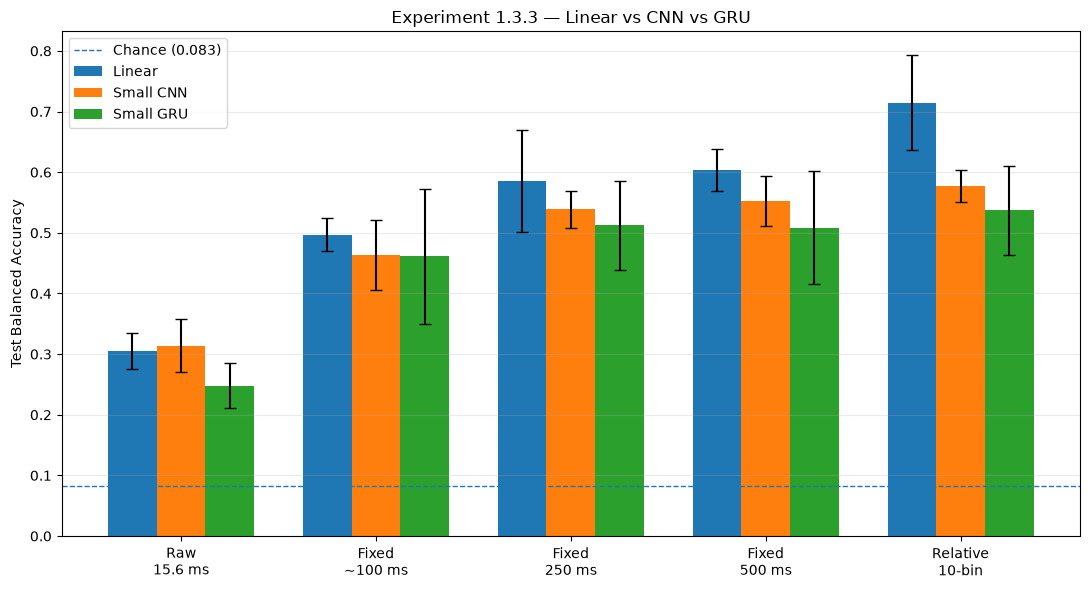

In [13]:
order=list(REPRESENTATIONS)
labels={"raw_timestep":f"Raw\n{1000/SAMPLING_RATE_HZ:.1f} ms",
        "fixed_100ms":"Fixed\n~100 ms","fixed_250ms":"Fixed\n250 ms",
        "fixed_500ms":"Fixed\n500 ms","relative_10bin":"Relative\n10-bin"}
x=np.arange(len(order)); width=0.25
fig,ax=plt.subplots(figsize=(11,6))
for off,name,disp in ((-width,"linear","Linear"),(0,"small_temporal_cnn","Small CNN"),(width,"small_temporal_gru","Small GRU")):
    s=summary[summary.model==name].set_index("representation").loc[order]
    ax.bar(x+off,s.mean_test_ba,width=width,yerr=s.sd_test_ba,capsize=4,label=disp)
ax.axhline(1/N_CLASSES,ls="--",lw=1,label=f"Chance ({1/N_CLASSES:.3f})")
ax.set_xticks(x); ax.set_xticklabels([labels[r] for r in order])
ax.set_ylabel("Test Balanced Accuracy")
ax.set_title("Experiment 1.3.3 — Linear vs CNN vs GRU")
ax.grid(axis="y",alpha=.25); ax.legend()
plt.tight_layout(); plt.show()

## 13. Decoder-gain visualization

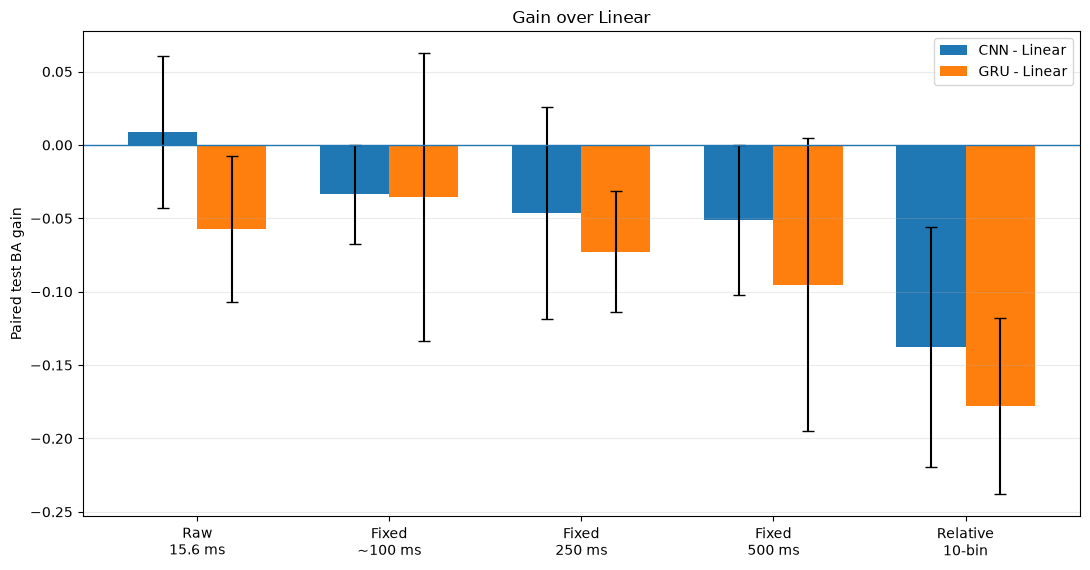

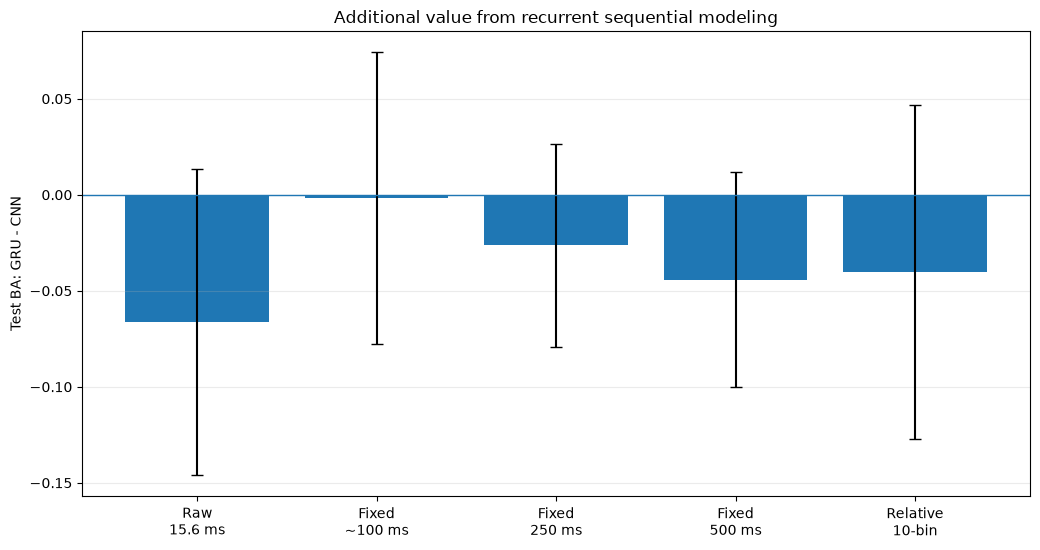

In [14]:
g=gain_summary.set_index("representation").loc[order]
x=np.arange(len(order)); width=.36
fig,ax=plt.subplots(figsize=(11,5.8))
ax.bar(x-width/2,g.mean_cnn_minus_linear,width,yerr=g.sd_cnn_minus_linear,capsize=4,label="CNN - Linear")
ax.bar(x+width/2,g.mean_gru_minus_linear,width,yerr=g.sd_gru_minus_linear,capsize=4,label="GRU - Linear")
ax.axhline(0,lw=1); ax.set_xticks(x); ax.set_xticklabels([labels[r] for r in order])
ax.set_ylabel("Paired test BA gain"); ax.set_title("Gain over Linear")
ax.grid(axis="y",alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

fig,ax=plt.subplots(figsize=(10.5,5.6))
ax.bar(x,g.mean_gru_minus_cnn,yerr=g.sd_gru_minus_cnn,capsize=4)
ax.axhline(0,lw=1); ax.set_xticks(x); ax.set_xticklabels([labels[r] for r in order])
ax.set_ylabel("Test BA: GRU - CNN")
ax.set_title("Additional value from recurrent sequential modeling")
ax.grid(axis="y",alpha=.25); plt.tight_layout(); plt.show()

## 14. Validation BA vs epoch

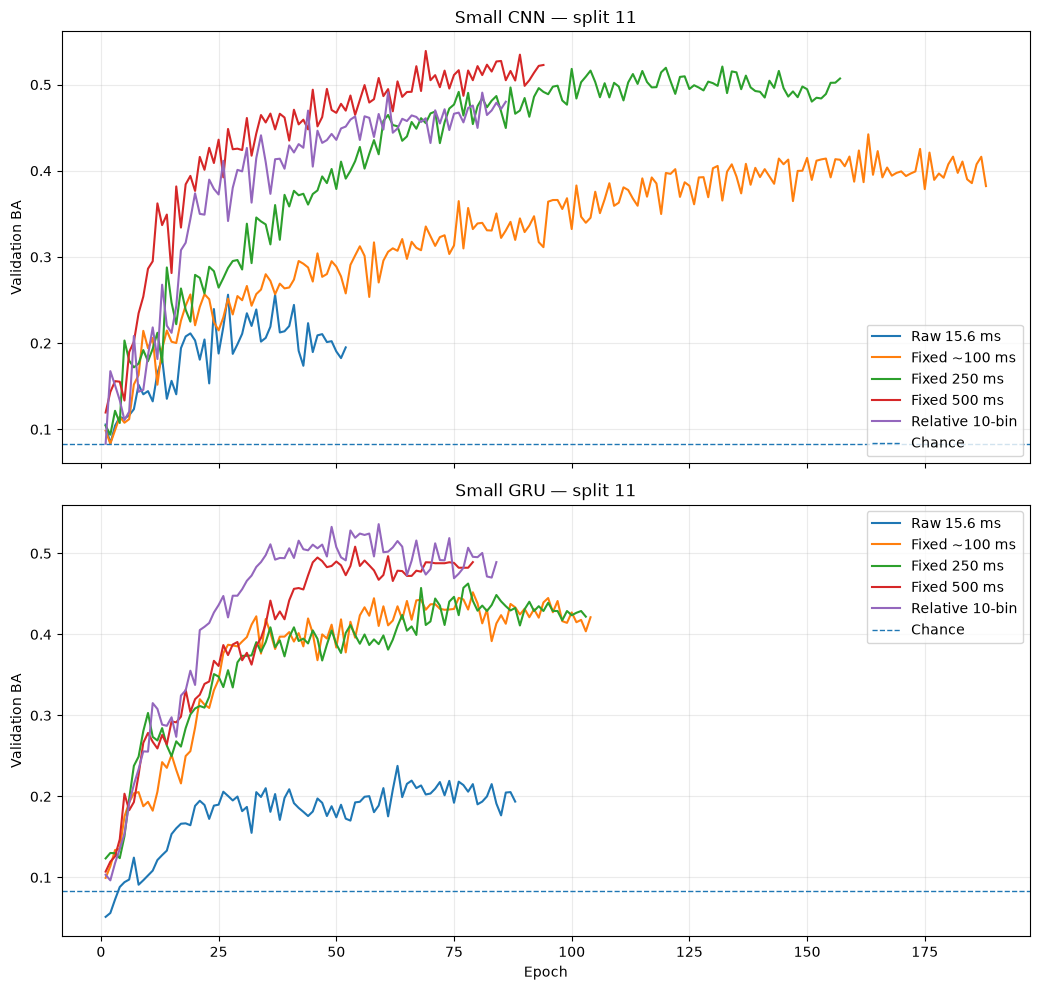

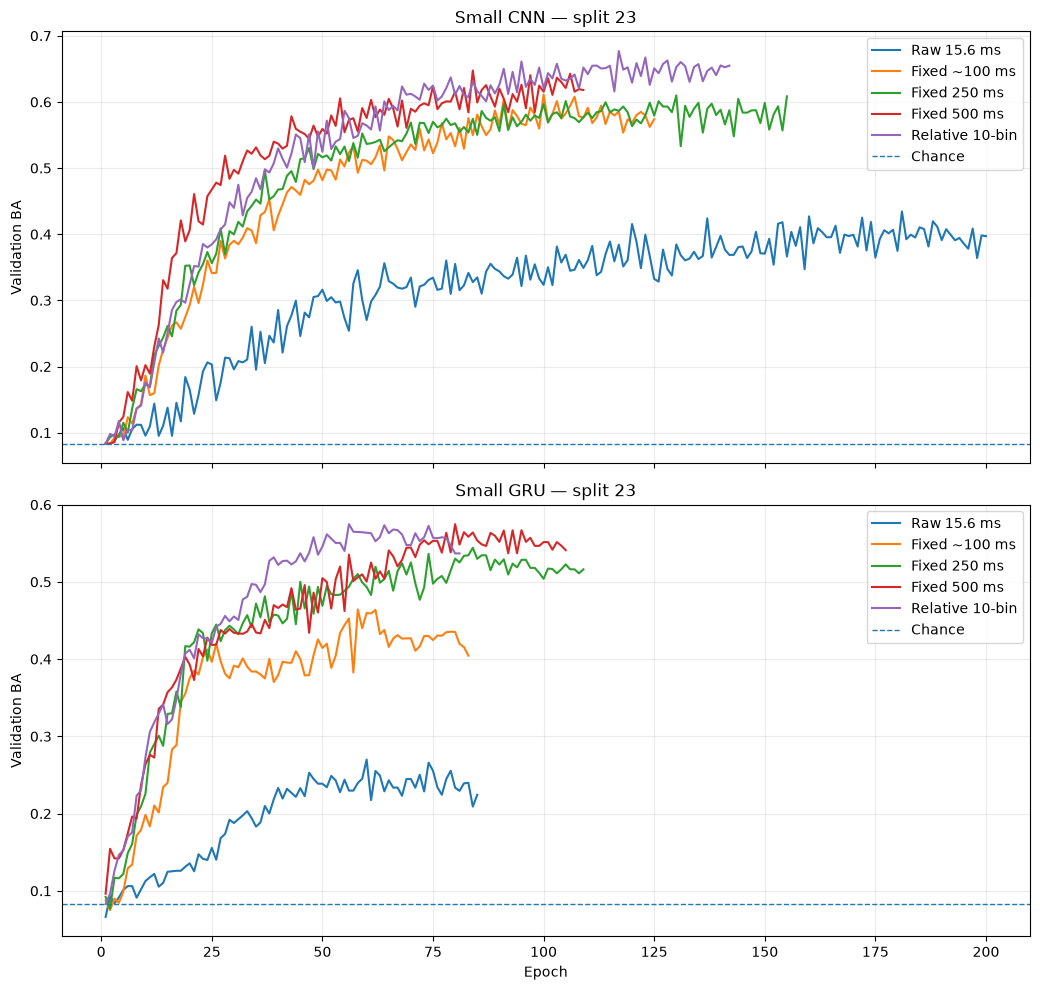

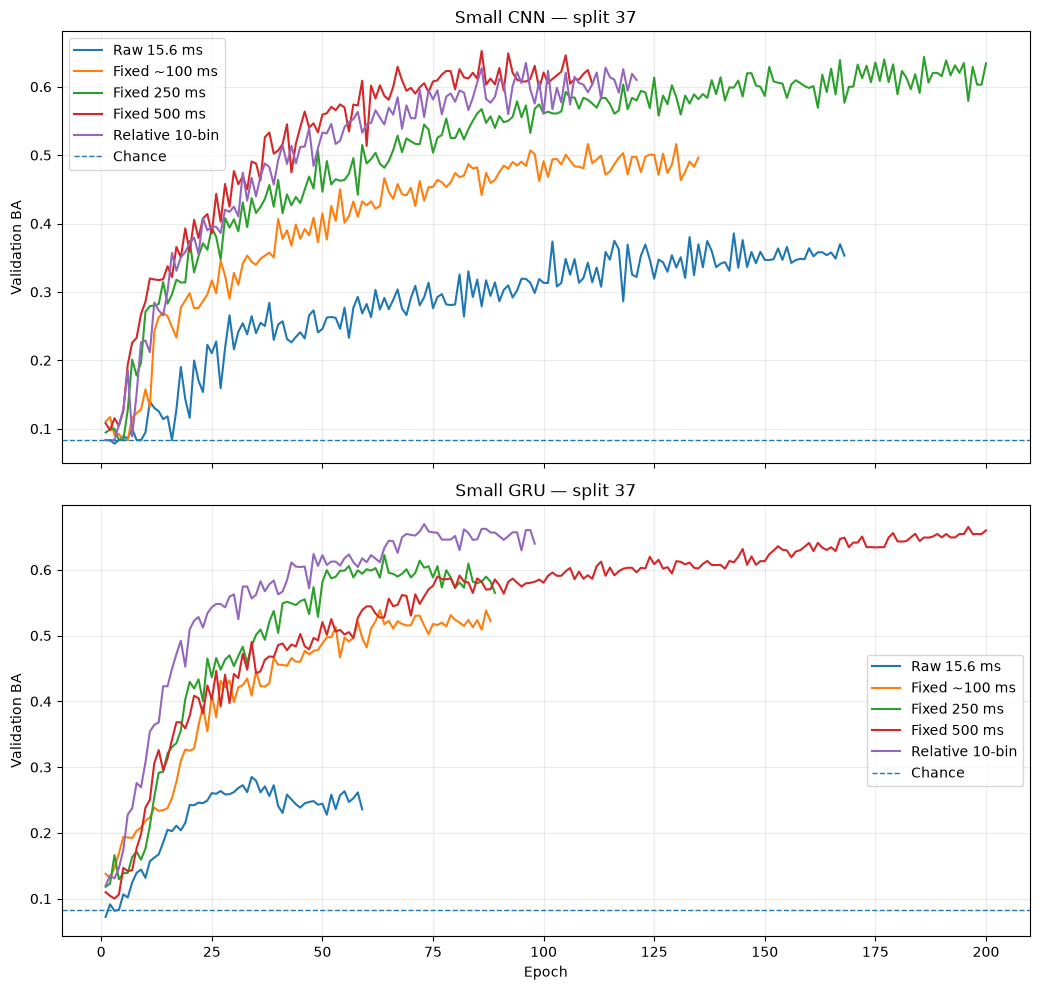

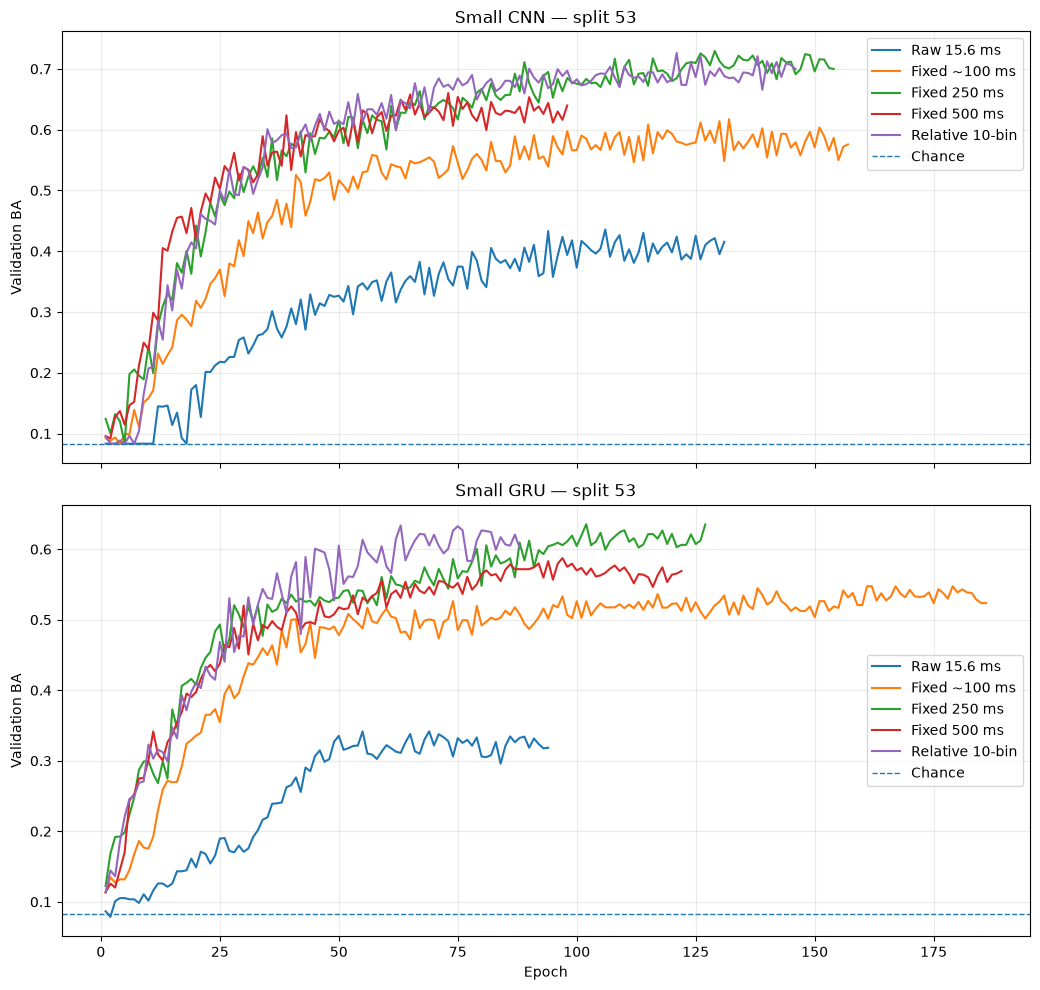

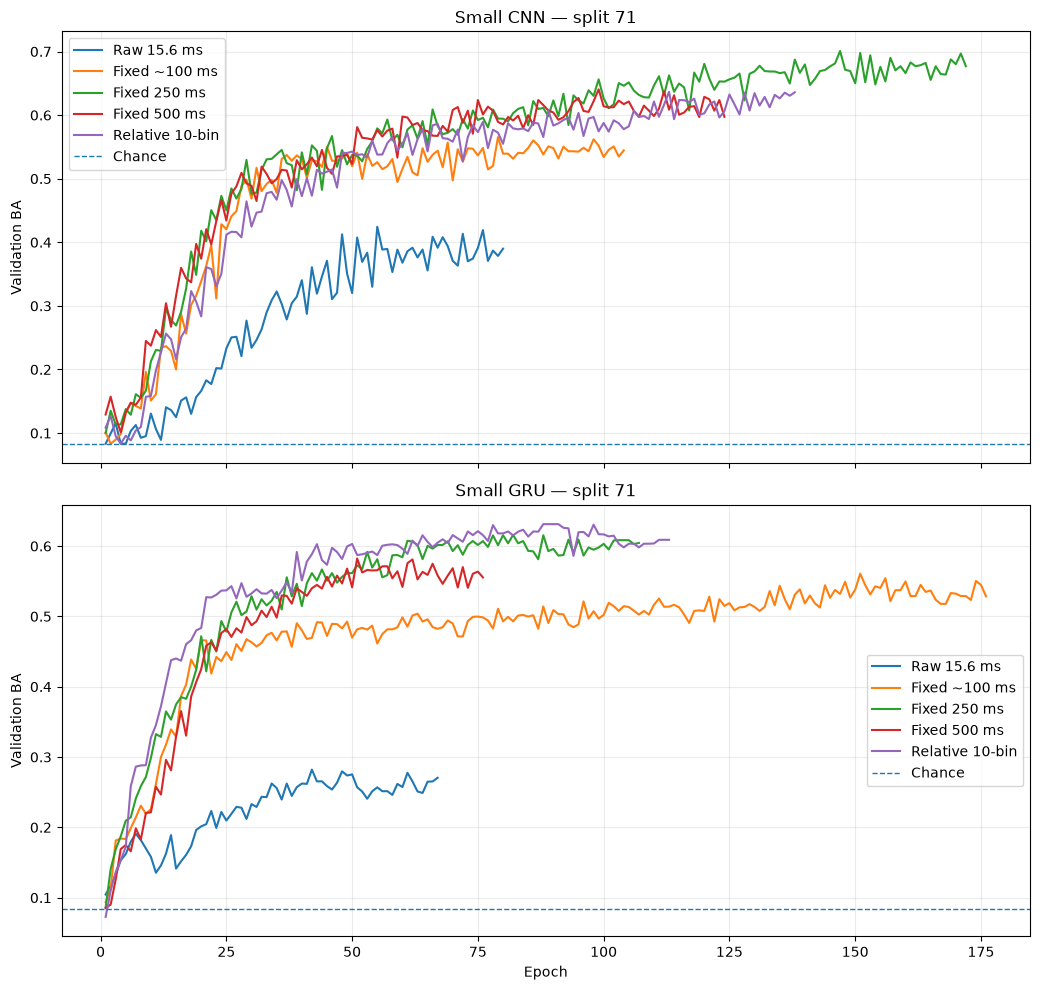

In [15]:
for split_seed in SPLIT_SEEDS:
    fig,axes=plt.subplots(2,1,figsize=(10.5,10),sharex=True)
    for ax,model_name,title in ((axes[0],"small_temporal_cnn","Small CNN"),
                                (axes[1],"small_temporal_gru","Small GRU")):
        sdf=training_history[(training_history.split_seed==split_seed)&(training_history.model==model_name)]
        for rep in order:
            r=sdf[sdf.representation==rep].sort_values("epoch")
            ax.plot(r.epoch,r.val_balanced_accuracy,label=labels[rep].replace("\n"," "))
        ax.axhline(1/N_CLASSES,ls="--",lw=1,label="Chance")
        ax.set_ylabel("Validation BA"); ax.set_title(f"{title} — split {split_seed}")
        ax.grid(alpha=.25); ax.legend()
    axes[-1].set_xlabel("Epoch")
    plt.tight_layout(); plt.show()

## 15. Per-split comparison

In [16]:
per_split=wide.rename(columns={
    "linear":"test_ba_linear",
    "small_temporal_cnn":"test_ba_cnn",
    "small_temporal_gru":"test_ba_gru",
})
display(per_split.sort_values(["split_seed","representation"]))

model,split_seed,representation,test_ba_linear,test_ba_cnn,test_ba_gru,cnn_minus_linear,gru_minus_linear,gru_minus_cnn
0,11,fixed_100ms,0.519553,0.537779,0.637956,0.018226,0.118403,0.100177
1,11,fixed_250ms,0.683184,0.547535,0.606972,-0.135648,-0.076212,0.059436
2,11,fixed_500ms,0.647699,0.591755,0.559743,-0.055944,-0.087956,-0.032013
3,11,raw_timestep,0.287241,0.294186,0.243171,0.006944,-0.044070,-0.051014
4,11,relative_10bin,0.817824,0.555304,0.628036,-0.262520,-0.189788,0.072733
5,23,fixed_100ms,0.482232,0.430176,0.341830,-0.052056,-0.140402,-0.088346
6,23,fixed_250ms,0.537563,0.531422,0.471716,-0.006141,-0.065847,-0.059706
7,23,fixed_500ms,0.571126,0.527678,0.475494,-0.043448,-0.095632,-0.052184
8,23,raw_timestep,0.328467,0.332590,0.237211,0.004123,-0.091256,-0.095379
9,23,relative_10bin,0.683647,0.593679,0.425953,-0.089968,-0.257693,-0.167726


## 16. Selectable normalized confusion matrix

Change `CM_MODEL`, `CM_REPRESENTATION`, `CM_SPLIT_SEED`, and `CM_EVAL_SPLIT` to inspect any saved Linear/CNN/GRU condition without retraining.

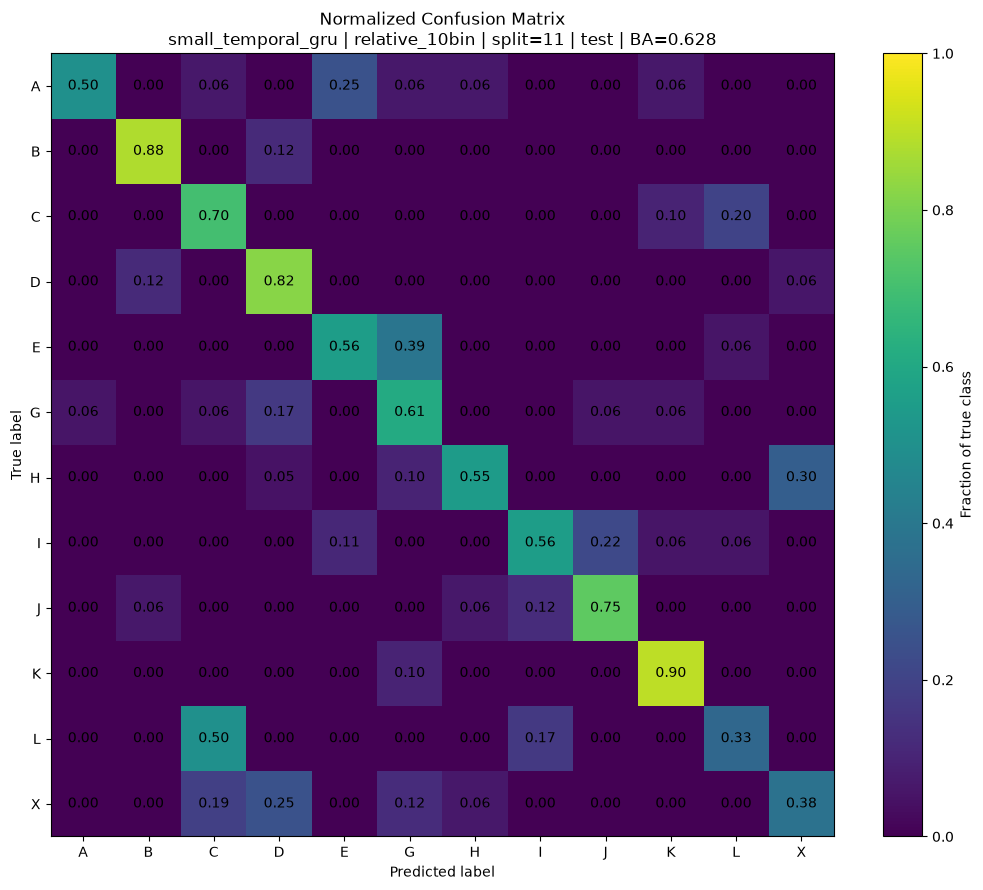

In [17]:
CM_MODEL = "small_temporal_gru"      # "linear", "small_temporal_cnn", "small_temporal_gru"
CM_REPRESENTATION = "relative_10bin" # any item in REPRESENTATIONS
CM_SPLIT_SEED = SPLIT_SEEDS[0]
CM_EVAL_SPLIT = "test"               # "val" or "test"

s=predictions[(predictions.model==CM_MODEL)&
              (predictions.representation==CM_REPRESENTATION)&
              (predictions.split_seed==CM_SPLIT_SEED)&
              (predictions.eval_split==CM_EVAL_SPLIT)].copy()
if s.empty:
    raise ValueError("No saved predictions match the selected condition")

y=s.y_true.to_numpy(int); p=s.y_pred.to_numpy(int)
cm=confusion_matrix(y,p,labels=np.arange(N_CLASSES),normalize="true")
ba=balanced_accuracy_score(y,p)

fig,ax=plt.subplots(figsize=(10.5,9))
im=ax.imshow(cm,vmin=0,vmax=1,aspect="auto")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j,i,f"{cm[i,j]:.2f}",ha="center",va="center")
ax.set_xticks(np.arange(N_CLASSES)); ax.set_yticks(np.arange(N_CLASSES))
ax.set_xticklabels(labels_sorted); ax.set_yticklabels(labels_sorted)
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
ax.set_title(f"Normalized Confusion Matrix\n{CM_MODEL} | {CM_REPRESENTATION} | split={CM_SPLIT_SEED} | {CM_EVAL_SPLIT} | BA={ba:.3f}")
cbar=fig.colorbar(im,ax=ax); cbar.set_label("Fraction of true class")
plt.tight_layout(); plt.show()

## Interpretation guide

- **CNN ~= Linear, GRU ~= CNN:** temporal decoder complexity adds little; the representation itself exposes most usable information.
- **CNN > Linear, GRU ~= CNN:** local temporal motifs matter, but recurrent state adds little beyond convolution.
- **GRU > CNN > Linear:** sequential composition and accumulated temporal state matter; this supports adding recurrence in later SNN phases.
- **Raw GRU > Raw CNN/Linear:** recurrence is more tolerant to absolute timing variation than coordinate-specific linear weights.
- **Fixed 100/250/500 ms GRU peak:** short-time integration followed by sequential modeling is useful. The winning bin duration is a representation scale, not a literal optimal `tau_syn`.
- **Relative-10 GRU remains strongest:** cross-user gesture-phase normalization remains the strongest alignment cue.
- **Fixed GRU catches Relative-10 GRU:** recurrence compensates for some speed/warping variation, which is encouraging for streaming fixed-time processing.

The CNN and GRU are intentionally close in parameter count, but they still have different inductive biases: CNN extracts local motifs then pools globally, whereas GRU recursively accumulates state across the full valid sequence.